In [1]:
from ISMgas.fitting.systemic_redshift import Fitter
from ISMgas.SupportingFunctions import load_QFitsview_spectra, overlayAllLines
import matplotlib.pyplot as plt 

(3500.0, 5824.0)

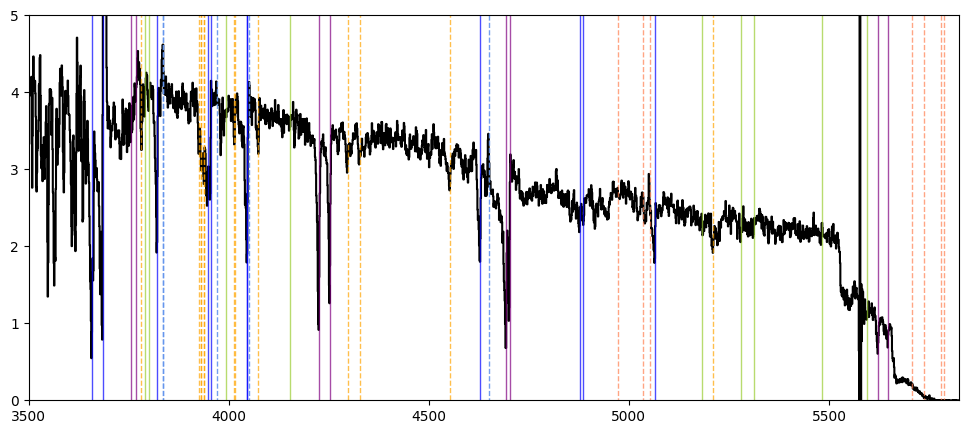

In [2]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec")

zs = 2.032 ## Guess redshift
overlayAllLines(zfactor = (1+zs))

flux *= 1e-2
## Make a mock error spectra
error_mock = flux*0.1
plt.ylim([0,5])
plt.xlim([3500, wave[-1]])

Running 2Running 1Running 0Running 4Running 6Running 3Running 9Running 7Running 8


Running 5Running 10Running 12Running 11



Running 13


Running 14




Running 15
Running 16
Running 17
Running 18
Running 19


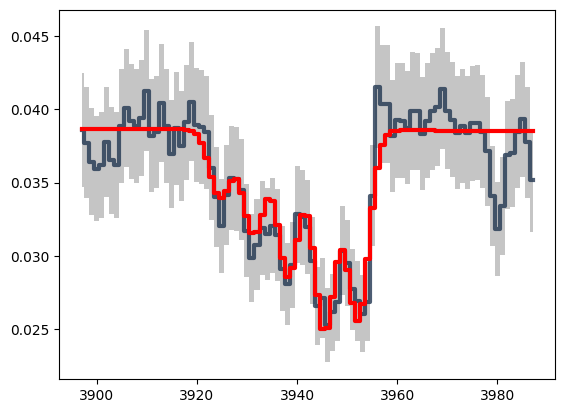

In [3]:
zFit = Fitter(
    wave = wave,
    flux= flux,
    err = error_mock,
    zs = zs,
    objid = 'test'
)
priors = {
        'p0':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p1':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p2':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p3':{'value':-0.00001, 'min':-0.04,   'max':0},
        'p4':{'value':-0.00001, 'min':-0.04,   'max':0},
        'p5':{'value':-0.001,  'min':-0.05,   'max':0},
        'p6':{'value':0.001,   'min':0, 'max':0.000001},
        'z1':{'value':zs, 'min':zs - 0.001, 'max':zs + 0.001},
        'z2':{'value':zs - 0.002, 'min':zs - 0.005, 'max':zs + 0.005},
        'z3':{'value':zs, 'min':zs - 0.001, 'max':zs + 0.001},   
        'sigma1':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'sigma2':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'sigma3':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'p9':{'value':0.05,   'min':-0.05, 'max':1},
        'p10':{'value':-0.001,  'min':-1, 'max':1 }
    }

results = zFit.stellar1300(niter=20, plotting=True, priors=priors)

In [4]:
results

{'best_fit': {'zstars': [2.0318037381072385, 0.0002716824304868534],
  'zism': [2.0298989671472514, 0.0001829081277831895],
  'zfineem': [2.0313614213281883, 0.000512746568253722],
  'sigma_stellar': [0.00021143958386558978, 1.8378489739159815e-05],
  'sigma_ism': [0.00021717848180310127, 1.562871114435445e-05],
  'sigma_fineem': [0.0002950730035845561, 0.00019275775489392693],
  'p0': [-0.004633518464007766, 0.0016028731226668698],
  'p1': [-4.515369572418229e-05, 6.68889984961361e-05],
  'p2': [-0.0070696804213374355, 0.002049987418824587],
  'p3': [-0.009964379715952806, 0.0011316687132917156],
  'p4': [-0.013719595605511233, 0.0010124431137578916],
  'p5': [-0.0128718779231706, 0.0009569571854214662],
  'p6': [7.537635493965903e-07, 3.237106375886122e-07],
  'p9': [0.06088806856504241, 0.010834467839519704],
  'p10': [0.25013078162779934, 0.07005280515855558],
  'wave': <Column name='Wave' dtype='float64' length=91>
  3897.0
  3898.0
  3899.0
  3900.0
  3901.0
  3902.0
  3903.0
  3

(3700.0, 4100.0)

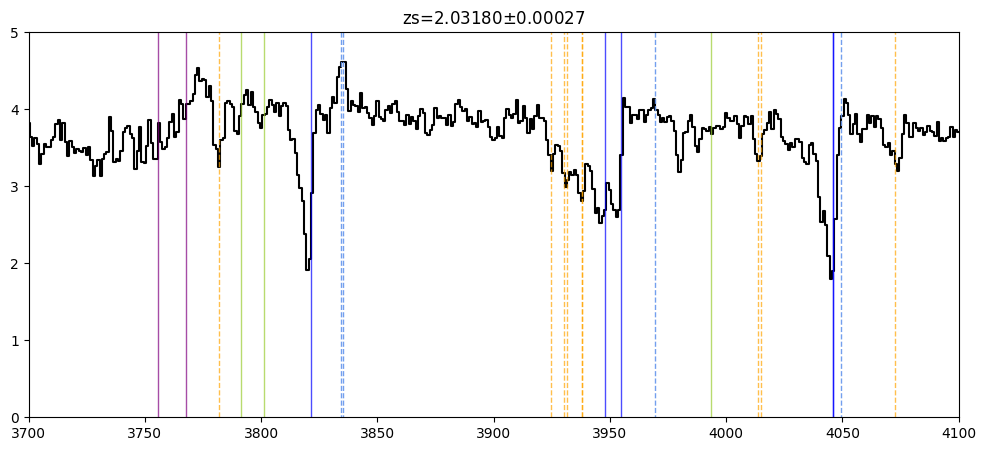

In [8]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec")

zs = results['best_fit']['zstars'][0] ## best fit redshift
zsErr = results['best_fit']['zstars'][1] ## error

overlayAllLines(zfactor = (1+zs))
plt.title(f"zs={zs:.5f}$\pm${zsErr:.5f}")
plt.ylim([0,5])
plt.xlim([3700, 4100])